In [ ]:
#!pip install --update entsoe-py 
from entsoe import EntsoePandasClient
from entsoe.exceptions import NoMatchingDataError, PaginationError
from requests.exceptions import HTTPError

import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path

API_KEY = "1206c24a-2fb6-4ec3-a47f-0e1be10dacd4"
client = EntsoePandasClient(api_key= API_KEY)

In [16]:
start = pd.Timestamp("2019-01-01", tz="Europe/Brussels")
end   = pd.Timestamp("2020-01-01", tz="Europe/Brussels")

country_code = "NL"

process_types = {
    "A51": "aFRR",
    "A47": "mFRR",
    "A46": "RR"
}
contract_terms = ["A13","A01","A02","A03","A04"]  # hourly,daily,weekly,monthly,yearly

available = []
missing = []
frames = []

#loop process type per contract term
for pt, pname in process_types.items():
    for term in contract_terms:
        try:
            df = client.query_contracted_reserve_prices(
                country_code= country_code,
                start=start, end=end,
                process_type=pt,
                type_marketagreement_type=term,
                psr_type=None
            )
            if df.empty:
                missing.append((pname, pt, term, "empty frame"))
                continue

            if isinstance(df, pd.Series):
                df = df.to_frame("price_eur_per_mw_term")
            else:
                numcol = "value" if "value" in df.columns else df.columns[0]
                df = df.rename(columns={numcol: "price_eur_per_mw_term"})[["price_eur_per_mw_term"]]

            df = df[~df.index.duplicated(keep="last")]
            df.index.name = "period_start"
            df["product"] = pname
            df["process_type"] = pt
            df["term_code"] = term
            frames.append(df)

            available.append((pname, pt, term, df.index.min(), df.index.max()))

        except NoMatchingDataError:
            missing.append((pname, pt, term, "NoMatchingData"))
        except Exception as e:
            missing.append((pname, pt, term, type(e).__name__))

print("AVAILABLE:")
for row in available:
    print(row)

print("\nMISSING:")
for row in missing:
    print(row)


AVAILABLE:
('aFRR', 'A51', 'A02', Timestamp('2019-01-01 00:00:00+0100', tz='Europe/Amsterdam'), Timestamp('2020-01-01 00:00:00+0100', tz='Europe/Amsterdam'))
('aFRR', 'A51', 'A03', Timestamp('2019-01-01 00:00:00+0100', tz='Europe/Amsterdam'), Timestamp('2020-01-01 00:00:00+0100', tz='Europe/Amsterdam'))

MISSING:
('aFRR', 'A51', 'A13', 'NoMatchingData')
('aFRR', 'A51', 'A01', 'NoMatchingData')
('aFRR', 'A51', 'A04', 'NoMatchingData')
('mFRR', 'A47', 'A13', 'NoMatchingData')
('mFRR', 'A47', 'A01', 'NoMatchingData')
('mFRR', 'A47', 'A02', 'NoMatchingData')
('mFRR', 'A47', 'A03', 'AttributeError')
('mFRR', 'A47', 'A04', 'NoMatchingData')
('RR', 'A46', 'A13', 'NoMatchingData')
('RR', 'A46', 'A01', 'NoMatchingData')
('RR', 'A46', 'A02', 'NoMatchingData')
('RR', 'A46', 'A03', 'NoMatchingData')
('RR', 'A46', 'A04', 'NoMatchingData')


In [ ]:
# map contract term codes
term_labels = {
    "A13": "hourly",
    "A01": "daily",
    "A02": "weekly",
    "A03": "monthly",
    "A04": "yearly"
}

# Build unique [product, process_type, term] from what you already found available
combos = sorted({(pname, pt, term) for (pname, pt, term, *_) in available})

dfs = {}

for pname, pt, term in combos:
    try:
        df = client.query_contracted_reserve_prices(
            country_code=country_code,
            start=start, end=end,
            process_type=pt,
            type_marketagreement_type=term,
            psr_type=None
        )
        if df.empty:
            continue

        # normalize to a single price column and clean index
        if isinstance(df, pd.Series):
            df = df.to_frame("price_eur_per_mw_term")
        else:
            numcol = "value" if "value" in df.columns else df.columns[0]
            df = df.rename(columns={numcol: "price_eur_per_mw_term"})[["price_eur_per_mw_term"]]

        df = df[~df.index.duplicated(keep="last")]
        df.index.name = "period_start"

        df["product"] = pname
        df["process_type"] = pt
        df["term_code"] = term
        df["term_name"] = term_labels.get(term, term).lower()

        tenor = df["term_name"].iloc[0]
        key = f"{country_code.lower()}_{pname.lower()}_{tenor}"
        if key in dfs:  # rare, but safe fallback
            key = f"{key}_{pt.lower()}"

        dfs[key] = df

    except Exception as e:
        print(f"Skipping {pname}-{pt}-{term}: {type(e).__name__}")

print("Created dataframes:", ", ".join(dfs.keys()))

Created dataframes: nl_afrr_weekly, nl_afrr_monthly


In [ ]:
# build hourly versions for every dataframe in the dict `dfs`
dfs_h = {}

for name, frame in dfs.items():
    frame = frame.sort_index()

    non_price_cols = [c for c in frame.columns if c != 'price_eur_per_mw_term']
    agg_map = {'price_eur_per_mw_term': 'mean', **{c: 'first' for c in non_price_cols}}

    out = (
        frame
        .resample('h', label='left', closed='left')
        .agg(agg_map)
    )

    dfs_h[f"{name}_h"] = out

Built hourly frames: nl_afrr_weekly_h, nl_afrr_monthly_h


In [ ]:
print(list(dfs_h.keys()))

print(dfs_h['nl_afrr_weekly_h'].head())
print("-"*90)
print(dfs_h['nl_afrr_monthly_h'].head())

['nl_afrr_weekly_h', 'nl_afrr_monthly_h']
                           price_eur_per_mw_term product process_type  \
period_start                                                            
2019-01-01 00:00:00+01:00                3982.27    aFRR          A51   
2019-01-01 01:00:00+01:00                3982.27    aFRR          A51   
2019-01-01 02:00:00+01:00                3982.27    aFRR          A51   
2019-01-01 03:00:00+01:00                3982.27    aFRR          A51   
2019-01-01 04:00:00+01:00                3982.27    aFRR          A51   

                          term_code term_name  
period_start                                   
2019-01-01 00:00:00+01:00       A02    weekly  
2019-01-01 01:00:00+01:00       A02    weekly  
2019-01-01 02:00:00+01:00       A02    weekly  
2019-01-01 03:00:00+01:00       A02    weekly  
2019-01-01 04:00:00+01:00       A02    weekly  
------------------------------------------------------------------------------------------
                   

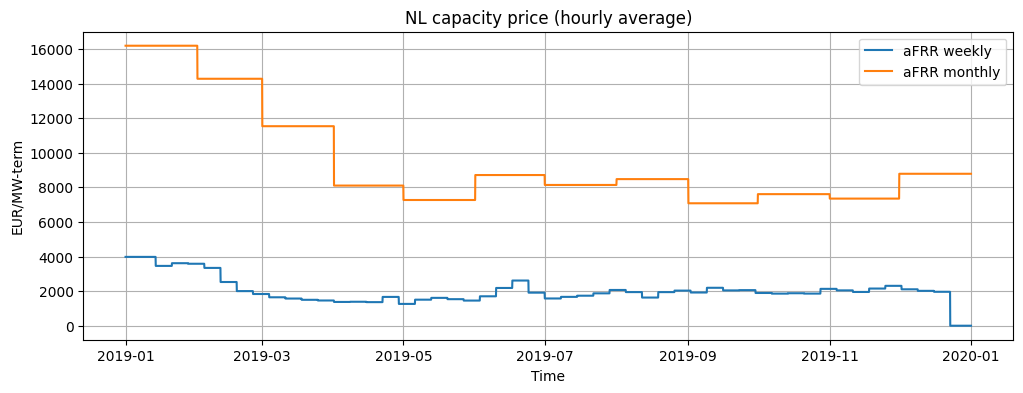

In [35]:
keys = ['nl_afrr_weekly_h', 'nl_afrr_monthly_h']

# get the price series
s_w = dfs_h[keys[0]]['price_eur_per_mw_term']
s_m = dfs_h[keys[1]]['price_eur_per_mw_term']

# align on the common hourly index (avoids gaps/mismatched ranges)
s_w, s_m = s_w.align(s_m, join='inner')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(s_w.index, s_w.values,
        label=f"{dfs_h[keys[0]]['product'].iat[0]} {dfs_h[keys[0]]['term_name'].iat[0]}")
ax.plot(s_m.index, s_m.values,
        label=f"{dfs_h[keys[1]]['product'].iat[0]} {dfs_h[keys[1]]['term_name'].iat[0]}")

ax.set_title(f"{country_code} capacity price (hourly average)")
ax.set_ylabel("EUR/MW-term")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True)
plt.show()
